In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
X = np.array([0,1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([0,0,0,0,0,0,1,1,1,1,1])

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
model = keras.Sequential([
    layers.Dense(8, activation="relu", input_shape=(1,)),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")   # binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [7]:
model.fit(X_train, y_train, epochs=100, verbose=0)

In [8]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", acc)

Test Accuracy: 1.0


In [18]:
new_value = np.array([[8]])
new_value_scaled = scaler.transform(new_value)

In [19]:
prediction = model.predict(new_value_scaled)
print("Prediction for X=5.5:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Class → 1")
else:
    print("Class → 0")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediction for X=5.5: 0.59838283
Class → 1


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


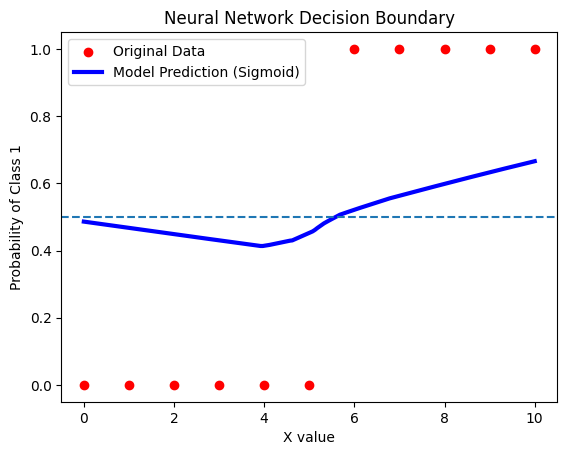

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# create many points to test model
X_range = np.linspace(0,10,200).reshape(-1,1)
X_range_scaled = scaler.transform(X_range)

# model predictions
y_prob = model.predict(X_range_scaled)

# plot
plt.scatter(X, y, color="red", label="Original Data")
plt.plot(X_range, y_prob, color="blue", linewidth=3, label="Model Prediction (Sigmoid)")

plt.axhline(0.5, linestyle="--")  # classification threshold
plt.xlabel("X value")
plt.ylabel("Probability of Class 1")
plt.title("Neural Network Decision Boundary")
plt.legend()
plt.show()
